### **Conclusions**
---
Titanic Data set contain 851 rows and 15 columns

There are 111 duplicates rows in the data set which removed

Age and Embarked columns has missing values

Dropped alive and embark_town columns  because they have same values with survival and embarked columns

Drop Deck column because it has 688 missing values

After dropping these columns we have 891 rows and 12 columns

In sex columns there are 577 males and 314 females

There  two missing values in the embarked column which imputed by sklearn 




## **Importing labraries**

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer

## **Loading data set**

In [3]:
df=sns.load_dataset('titanic')

## **Have a look on five random rows of the data**

In [4]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
102,0,1,male,21.0,0,1,77.2875,S,First,man,True,D,Southampton,no,False
205,0,3,female,2.0,0,1,10.4625,S,Third,child,False,G,Southampton,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
452,0,1,male,30.0,0,0,27.7500,C,First,man,True,C,Cherbourg,no,True
382,0,3,male,32.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True


## **Shape of the data**

In [5]:
df.shape

(891, 15)

## **Applying statics functions**

In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## **Columns of the data**

In [8]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

## **Missing values**

In [9]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Droping deck column because it has many missing values

In [10]:
df.drop('deck',axis=1,inplace=True)

In [11]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## Droping alive column because it is similar with the the survived column

In [12]:
df.drop('alive',axis=1,inplace=True)

## Droping Embarked_town column because embarked and embarked_town has some values

In [13]:
df.drop('embark_town',axis=1,inplace=True)

In [14]:
df.shape

(891, 12)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    str     
 3   age         714 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    889 non-null    str     
 8   class       891 non-null    category
 9   who         891 non-null    str     
 10  adult_male  891 non-null    bool    
 11  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(3)
memory usage: 65.5 KB


## **Survived Column**

In [35]:
df['survived'].head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [36]:
df['survived'].isnull().sum()

0

In [37]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

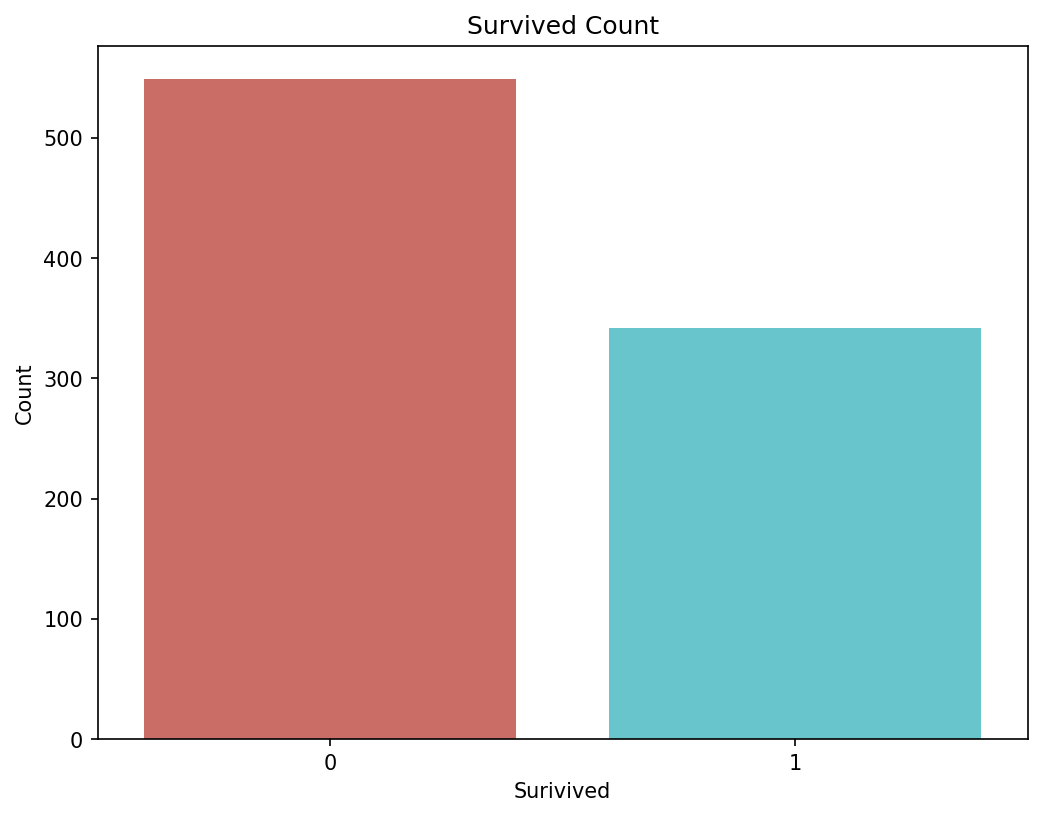

In [41]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(x='survived',data=df,palette='hls')
plt.title('Survived Count')
plt.xlabel('Surivived')
plt.ylabel('Count')
plt.show()

In [42]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,True


## **Pclass Column**

In [44]:
df['pclass'].head()

0    3
1    1
2    3
3    1
4    3
Name: pclass, dtype: int64

In [45]:
df['pclass'].isnull().sum()

0

In [46]:
df['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

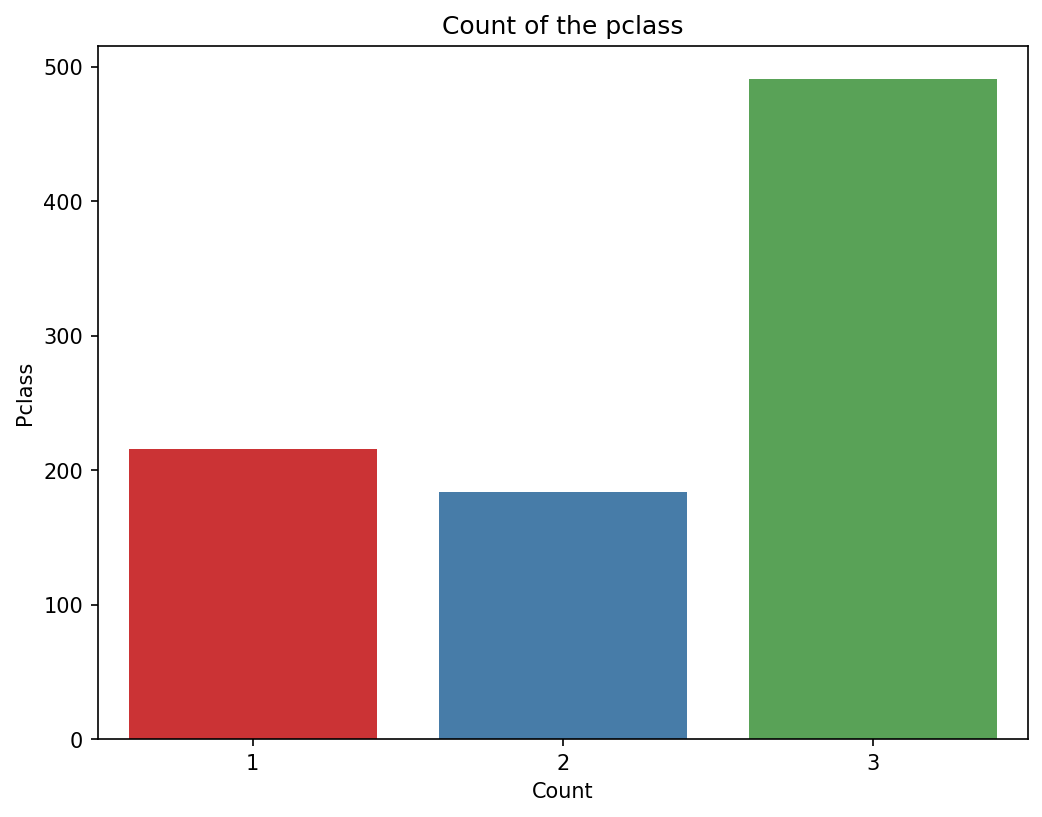

In [49]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(data=df,x='pclass',palette='Set1')
plt.title('Count of the pclass')
plt.xlabel('Count')
plt.ylabel('Pclass')
plt.show()


In [50]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,True


## **Sex column**

In [52]:
df['sex'].head()

0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: str

In [54]:
df['sex'].isnull().sum()

0

In [55]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

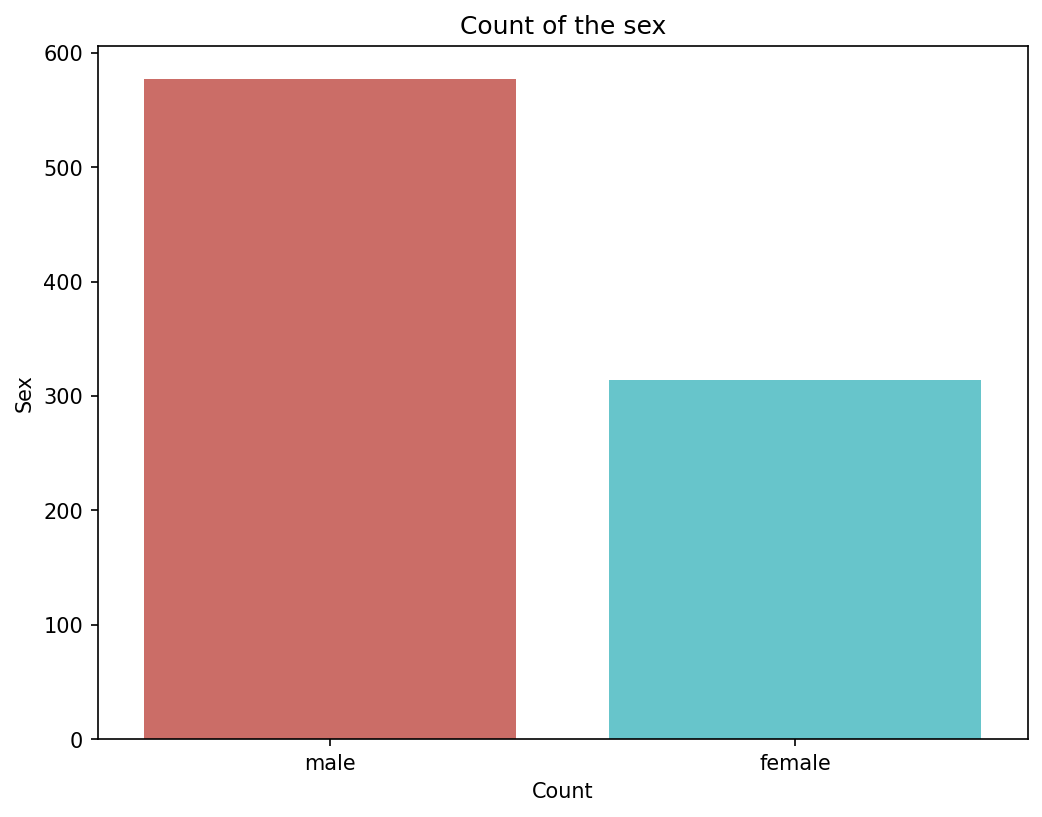

In [57]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(data=df,x='sex',palette='hls')
plt.title('Count of the sex')
plt.xlabel('Count')
plt.ylabel('Sex')
plt.show()

In [58]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,True


## **Age column**

In [60]:
df['age'].head()

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: age, dtype: float64

In [65]:
df['age'].isnull().sum()

177

## Filling these values with the sklearn

In [66]:
i=SimpleImputer(strategy='mean')
df['age']=i.fit_transform(df[['age']]).ravel()

In [67]:
df['age'].isnull().sum()

0

In [68]:
df['age'].dtype

dtype('float64')

### Changing type of the age column from floatto int 

In [69]:
## Changing data type 
df['age'] = df['age'].astype('int64')

In [70]:
df['age'].dtype

dtype('int64')

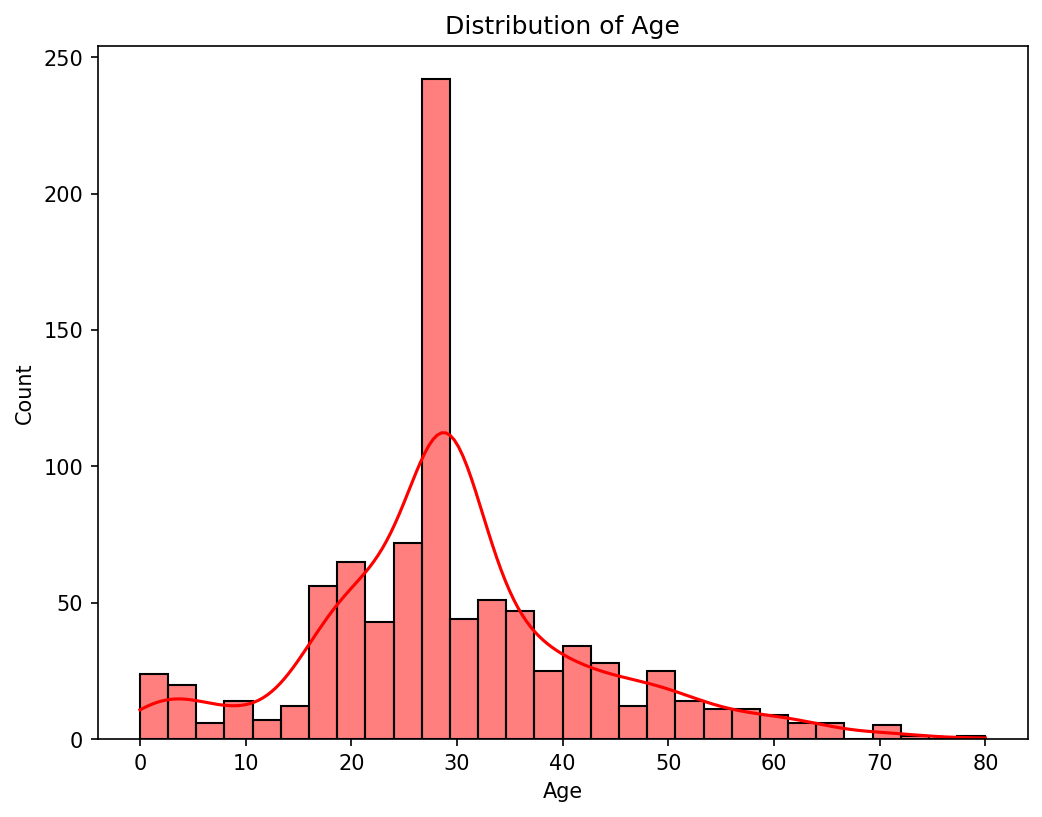

In [72]:
plt.figure(figsize=(8,6),dpi=150)
sns.histplot(data=df,x='age',bins=30,kde=True,color='red')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

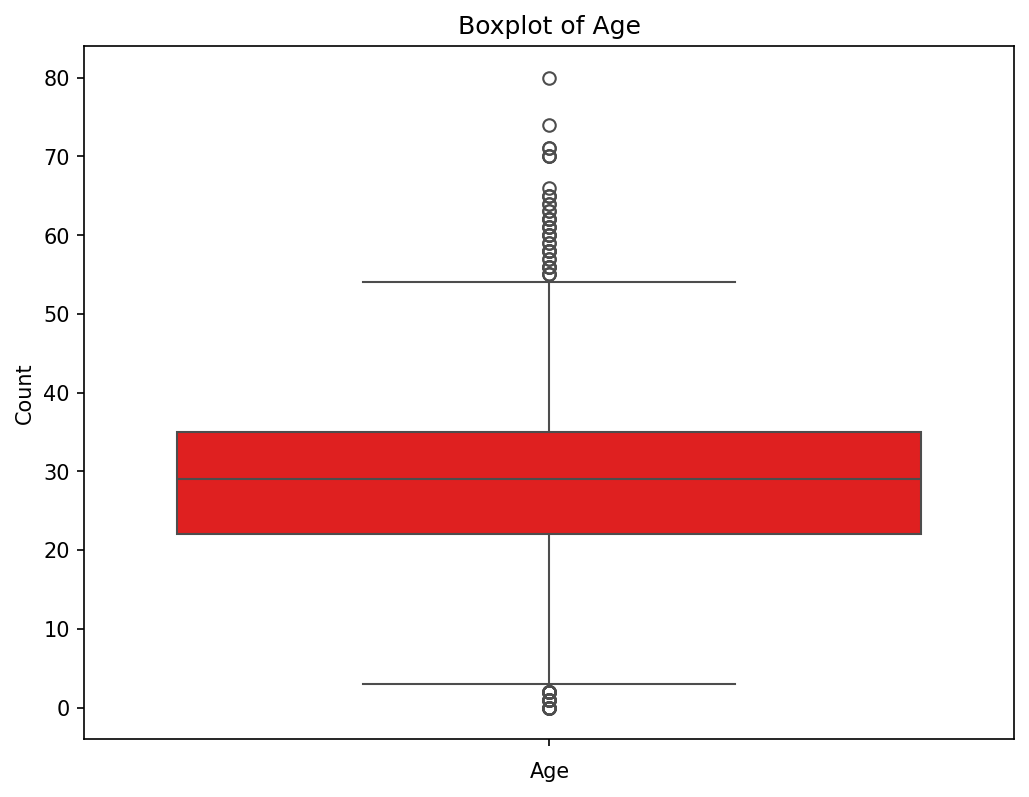

In [75]:
plt.figure(figsize=(8,6),dpi=150)
sns.boxplot(data=df,y='age',color='red')
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [77]:
f1=px.histogram(df, x='age', nbins=30, title='Distribution of Age', labels={'age': 'Age'}, color_discrete_sequence=['red'])
f1.update_layout(
    xaxis_title='Age',
    yaxis_title='Count'
)
f1.show()

In [78]:
f2=px.box(df, y='age', title='Boxplot of Age', labels={'age': 'Age'}, color_discrete_sequence=['red']).update_layout(
    yaxis_title='Age',
    xaxis_title='Count'
)
f2.show()

In [79]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35,0,0,8.0500,S,Third,man,True,True


## **Sibsp Column**

In [83]:
df['sibsp'].sample(5)

691    0
860    2
380    0
557    0
425    0
Name: sibsp, dtype: int64

In [84]:
df['sibsp'].isnull().sum()

0

In [85]:
df['sibsp'].value_counts()

sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

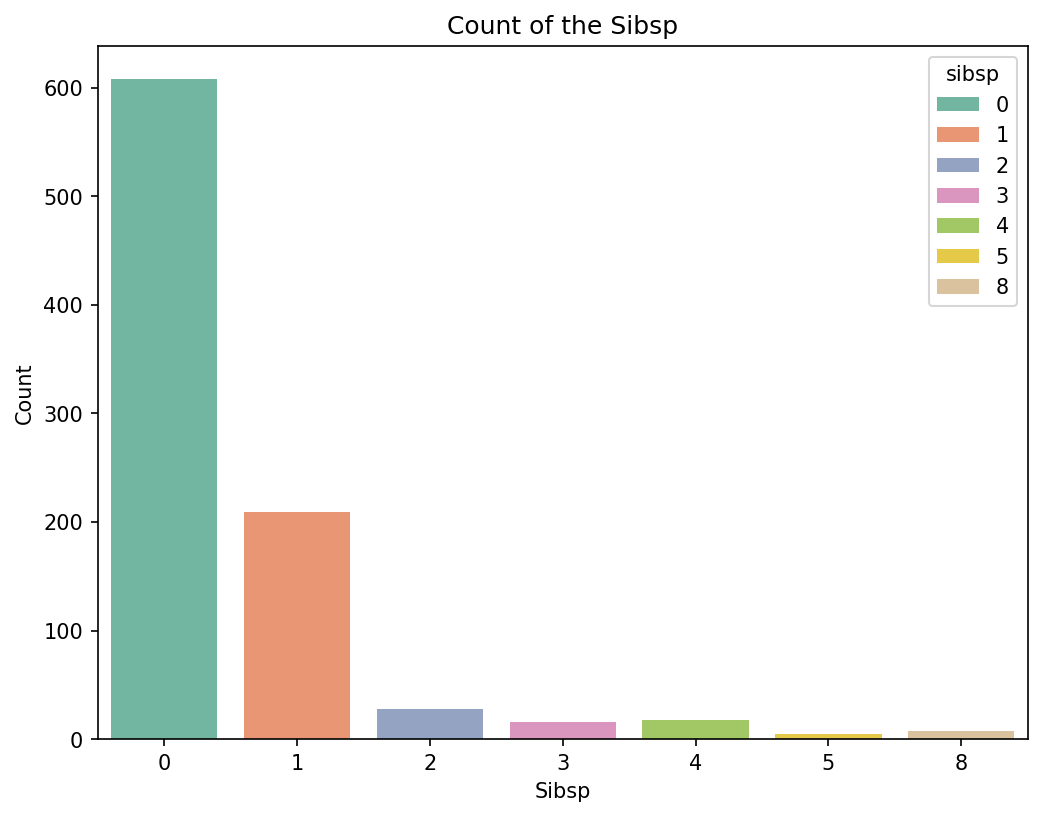

In [99]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(x='sibsp',data=df,hue='sibsp',palette='Set2')
plt.title('Count of the Sibsp')
plt.xlabel('Sibsp')
plt.ylabel('Count')
plt.show()

In [93]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35,0,0,8.0500,S,Third,man,True,True


## **Parch column**

In [95]:
df['parch'].sample(5)

448    1
371    0
483    0
14     0
788    2
Name: parch, dtype: int64

In [96]:
df['parch'].isnull().sum()

0

In [97]:
df['parch'].value_counts()

parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: xlabel='parch', ylabel='count'>

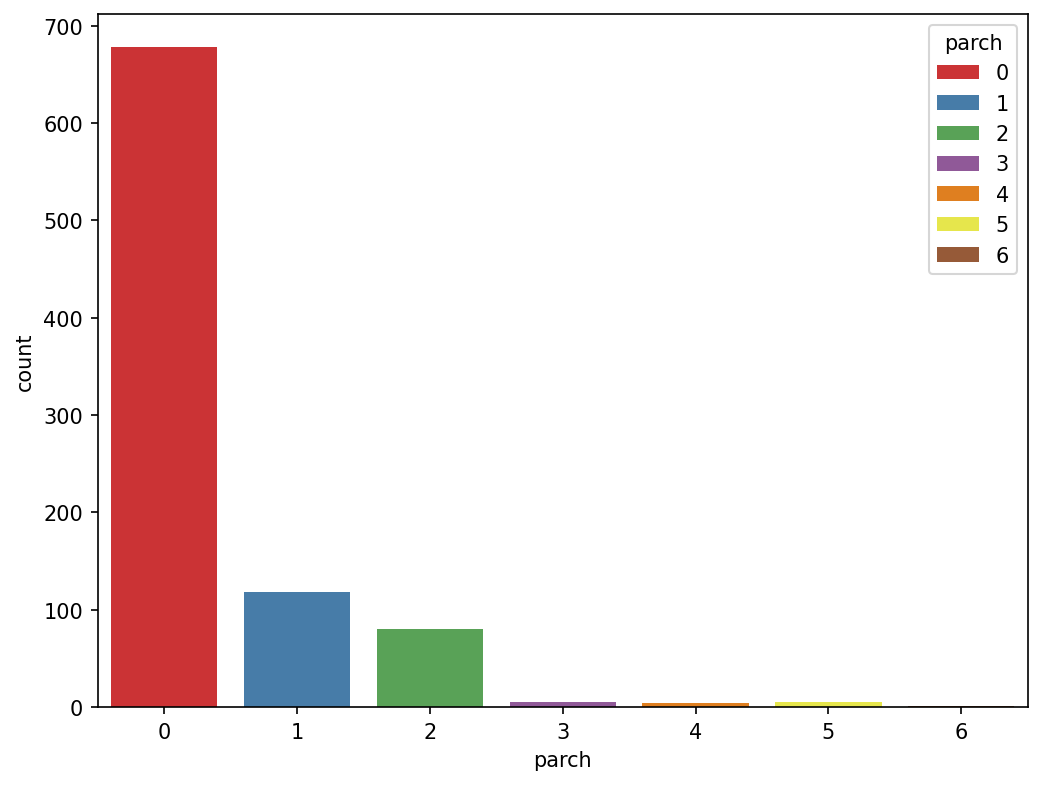

In [98]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(x='parch',data=df,hue='parch',palette='Set1')


In [100]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35,0,0,8.0500,S,Third,man,True,True


## **Fare column**

In [101]:
df['fare'].sample(5)

461      8.0500
325    135.6333
743     16.1000
211     21.0000
729      7.9250
Name: fare, dtype: float64

In [102]:
df['fare'].isnull().sum()

0

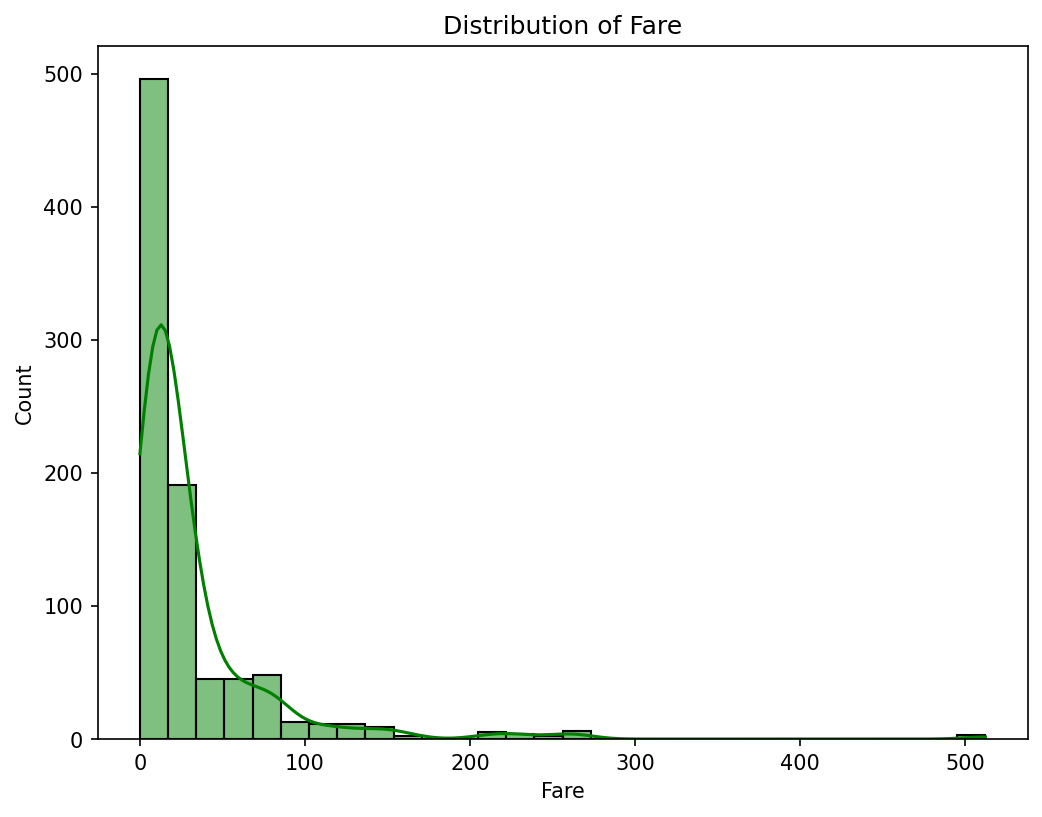

In [104]:
plt.figure(figsize=(8,6),dpi=150)
sns.histplot(data=df,x='fare',bins=30,kde=True,color='green')
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

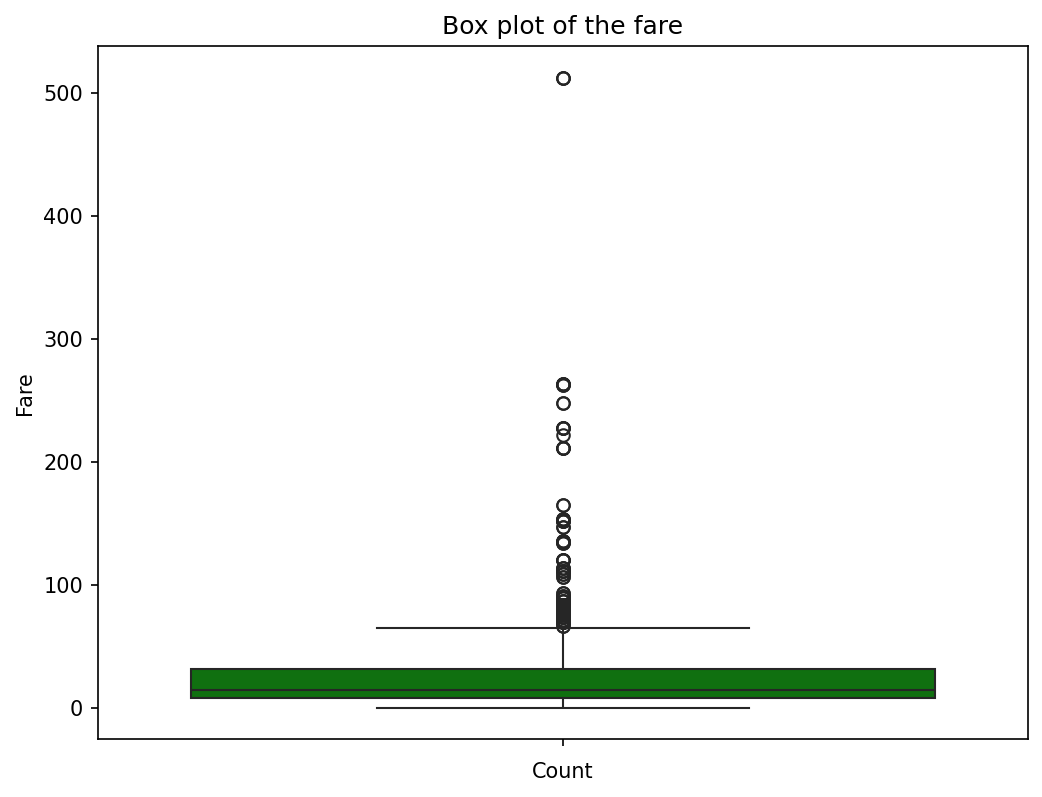

In [106]:
plt.figure(figsize=(8,6),dpi=150)
sns.boxplot(data=df,y='fare',color='green')
plt.title('Box plot of the fare')
plt.xlabel('Count')
plt.ylabel('Fare')
plt.show()

In [112]:
f3=px.histogram(df, x='fare', nbins=30, title='Distribution of Fare', color_discrete_sequence=['brown'])
f3.update_layout(xaxis_title='Fare', yaxis_title='Count')
f3.show()

In [ ]:
f4=px.box(df, y='fare', title='Boxplot of Fare', labels={'fare': 'Fare'}, color_discrete_sequence=['green']).update_layout(
    yaxis_title='fare',
    xaxis_title='Count'
)
f4.show()

In [113]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35,0,0,8.0500,S,Third,man,True,True


## **Embarked Column**

In [114]:
df['embarked'].sample(5)

266    S
510    Q
640    S
509    S
523    C
Name: embarked, dtype: str

In [116]:
df['embarked'].isnull().sum()

0

In [117]:
df['embarked'].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

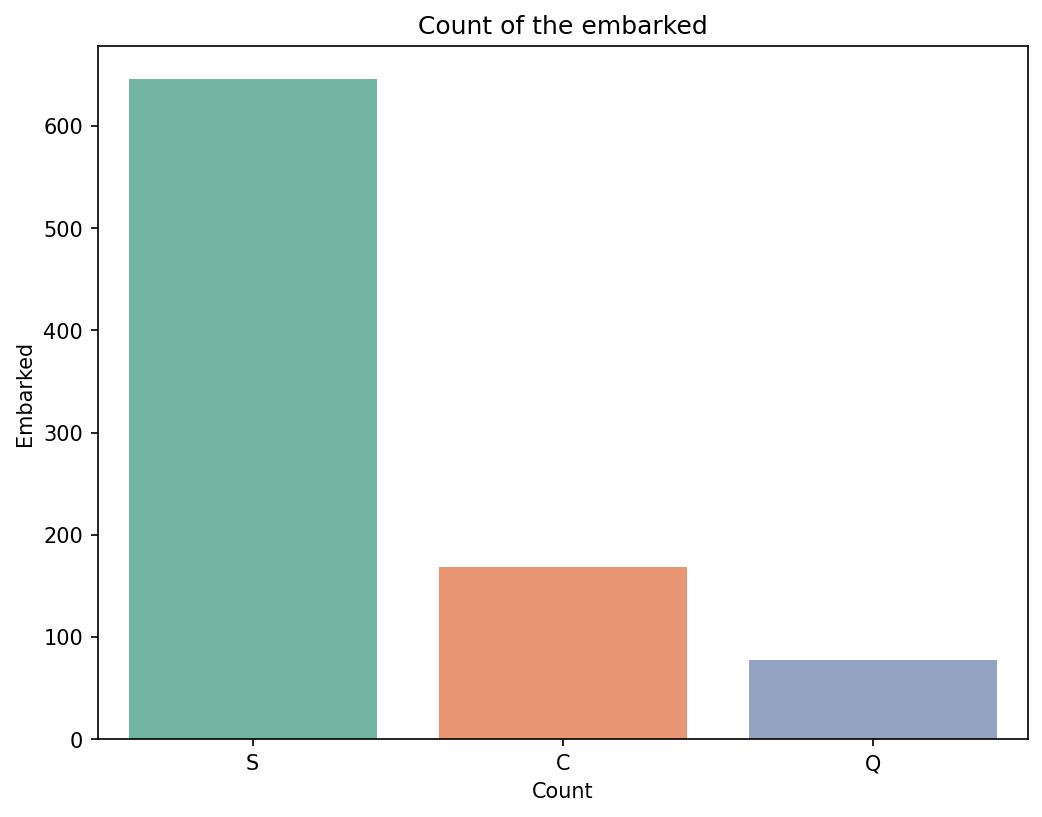

In [121]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(data=df,x='embarked',palette='Set2')
plt.title('Count of the embarked')
plt.xlabel('Count')
plt.ylabel('Embarked')
plt.show()

In [122]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35,0,0,8.0500,S,Third,man,True,True


## **Adult male column**

In [123]:
df['adult_male'].sample(5)

591    False
857     True
59     False
679     True
219     True
Name: adult_male, dtype: bool

In [124]:
df['adult_male'].isnull().sum()

0

In [125]:
df['adult_male'].value_counts()

adult_male
True     537
False    354
Name: count, dtype: int64

In [127]:
df['adult_male'].dtype

dtype('bool')

## Changing data type to integers

In [129]:
df['adult_male']=df['adult_male'].astype(int)

In [130]:
df['adult_male'].sample(5)

386    0
518    0
634    0
463    1
137    1
Name: adult_male, dtype: int32

In [134]:
df['adult_male'].value_counts()

adult_male
1    537
0    354
Name: count, dtype: int64

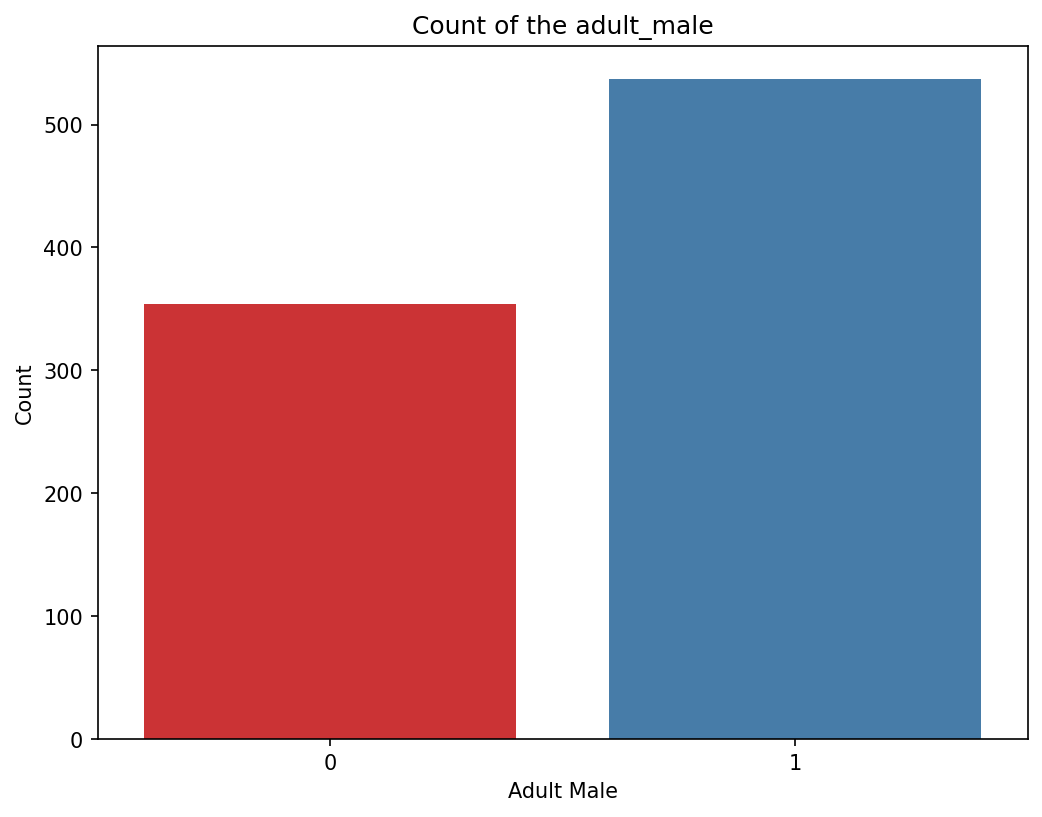

In [133]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(x='adult_male',data=df,palette='Set1')
plt.title('Count of the adult_male')
plt.xlabel('Adult Male')
plt.ylabel('Count')
plt.show()

In [135]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22,1,0,7.2500,S,Third,man,1,False
1,1,1,female,38,1,0,71.2833,C,First,woman,0,False
2,1,3,female,26,0,0,7.9250,S,Third,woman,0,True
3,1,1,female,35,1,0,53.1000,S,First,woman,0,False
4,0,3,male,35,0,0,8.0500,S,Third,man,1,True


## **Alone Column**

In [136]:
df['alone'].sample(5)

117    False
651    False
263     True
522     True
35     False
Name: alone, dtype: bool

In [137]:
df['alone'].dtype

dtype('bool')

## Changing data type in the integers

In [138]:
df['alone']=df['alone'].astype(int)

In [139]:
df['alone'].sample(5)

821    1
348    0
817    0
609    1
826    1
Name: alone, dtype: int32

In [140]:
df['alone'].value_counts()

alone
1    537
0    354
Name: count, dtype: int64

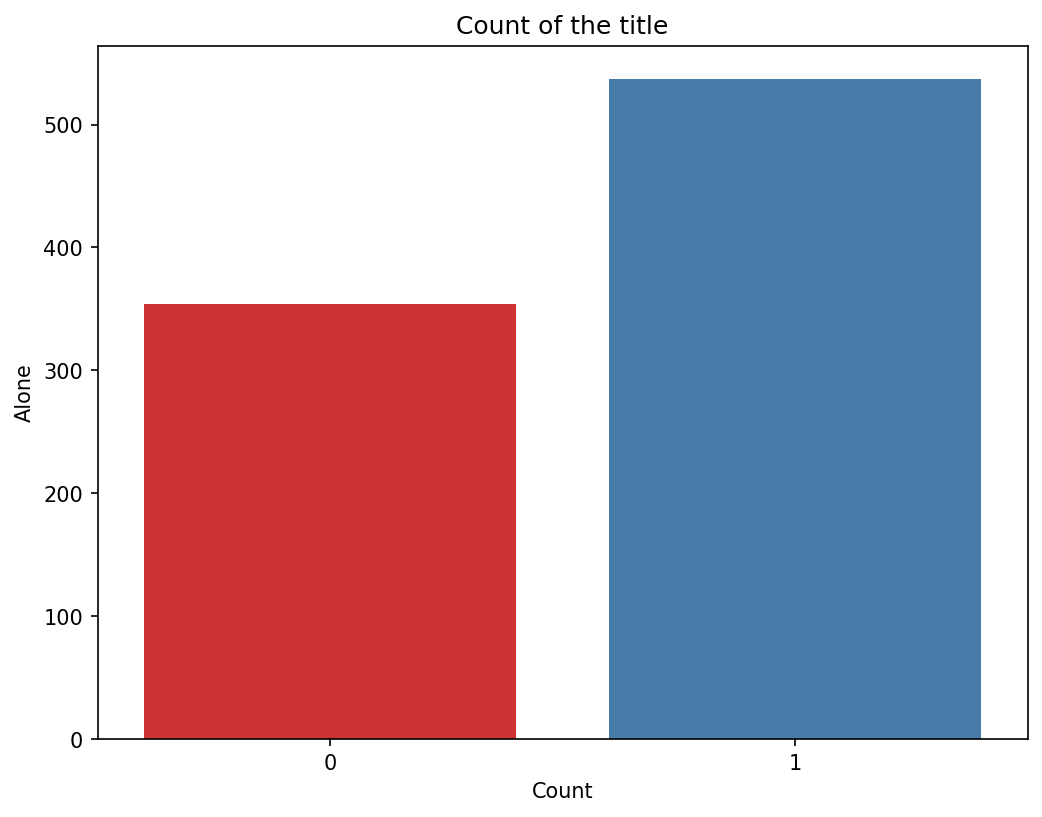

In [143]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(data=df,x='alone',palette='Set1')
plt.title('Count of the title')
plt.xlabel('Count')
plt.ylabel('Alone')
plt.show()